In [1]:
import json
import networkx as nx 
import numpy as np 
import pylab as plt 
import pandas as pd 
import seaborn as sns

In [2]:
# with open(f"metric_out/all_data.json", 'r') as fdata:
#     jsdata = json.load(fdata)

# with open(f"metric_out/NR_VisPub_graph.json", 'r') as fdata:
#     vispubdata = json.load(fdata)


# jsdata['VisPub'] = vispubdata

# with open("metric_out/all_data.json", 'w') as fdata:
#     json.dump(jsdata,fdata,indent=4)

In [3]:
import os 
listdf = list()

with open(f"metric_out/all_data.json", 'r') as fdata:
    jsdata = json.load(fdata)

for gname, gdict in jsdata.items():
    
    for method,ddata in gdict.items():
        for mtype, dddata in ddata.items():
            for metric, value in dddata.items():
                listdf.append([gname, method, mtype, metric, value])

listdf[0]

['InfoVis_graph', 'Naive FR', 'Rich', 'NH_7', 0.033866995073891626]

In [4]:
# df = pd.read_csv("generate/csv_files/performance-3.csv")
# df.head()
df = pd.DataFrame(listdf, columns=['Graph', "Method", "Metric Type", "Metric", "0"])
df.head()

,Graph,Method,Metric Type,Metric,0
0,InfoVis_graph,Naive FR,Rich,NH_7,0.033867
1,InfoVis_graph,Naive FR,Rich,SNS,0.487362
2,InfoVis_graph,Naive FR,Rich,SNKL,2.827175
3,InfoVis_graph,Naive FR,Sparse,NH_7,0.197121
4,InfoVis_graph,Naive FR,Sparse,SNS,0.448939


In [5]:
metricdf = df[df["Graph"] == "Dagstuhl"]
# metricdf = metricdf[metricdf['Metric Type'] == 'rich']
metricdf['typemetric'] = metricdf['Metric Type'] + '_' + metricdf['Metric']

/tmp/ipykernel_680257/3989096536.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metricdf['typemetric'] = metricdf['Metric Type'] + '_' + metricdf['Metric']


In [6]:
metricdf.head()

,Graph,Method,Metric Type,Metric,0,typemetric
768,Dagstuhl,Naive FR,Rich,NH_7,0.100529,Rich_NH_7
769,Dagstuhl,Naive FR,Rich,SNS,0.467421,Rich_SNS
770,Dagstuhl,Naive FR,Rich,SNKL,2.767329,Rich_SNKL
771,Dagstuhl,Naive FR,Sparse,NH_7,0.108142,Sparse_NH_7
772,Dagstuhl,Naive FR,Sparse,SNS,0.444354,Sparse_SNS


In [7]:
pivot_df = metricdf.pivot(index='Method', columns='typemetric', values='0')
pivot_df.head()

typemetric,Aesthetic_AR,Aesthetic_ELV,Aesthetic_ND,Between_Average Neighborhood radius (rich-view),Between_Average Neighborhood radius (sparse-view),Between_NH_7,Between_Neighborhood Preservation (r = 2),Between_SNKL,Between_SNS,Between_Shape faithfulness,Rich_NH_7,Rich_SNKL,Rich_SNS,Sparse_NH_7,Sparse_SNKL,Sparse_SNS
Method,,,,,,,,,,,,,,,,
Independent_R,0.921376,0.403916,0.574023,0.862745,0.882527,0.012930,0.123706,4.099969,0.395933,0.001253,0.100251,2.176055,0.410874,0.142583,2.593056,0.436133
Independent_S,0.925589,0.377223,0.596588,0.927841,0.960281,0.014463,0.123652,4.202451,0.403225,0.002356,0.092732,2.196528,0.408847,0.144281,2.605463,0.443137
Naive FR,0.892814,0.405643,0.601266,0.523072,0.414038,0.027117,0.107379,3.470222,0.408367,0.008278,0.100529,2.767329,0.467421,0.108142,3.002496,0.444354
Semantic,0.892131,0.669031,0.633737,0.834841,0.644371,0.046689,0.126480,3.629502,0.440811,0.016789,0.346979,1.545759,0.421246,0.116739,2.976087,0.459276
Union_FR,0.900675,0.445782,0.575949,0.556241,0.479098,0.025742,0.119436,3.437371,0.381643,0.008445,0.097187,2.301639,0.431727,0.106445,2.757275,0.435552


In [8]:
mmap = {
    "Poster_Method": "Semantic",
    "UnionGraph_-_Fruchtermann": "Union\\_FR",
    "UnionGraph_-_UMAP": "Union\\_UMAP", 
    "Two_Layer_+_Procrustes_Alignment_(Author_Proxy)": "Independent\\textsubscript{SA}",
    "Two_Layer_+_Procrustes_Alignment_(Paper_Proxy)": "Independent\\textsubscript{RA}", 
    "Rich_NH_7": "NH\\textsubscript{7}",
    "Rich_SNS": "SNS",
    "Rich_SNKL": "SNKL",
    "Sparse_NH_7": "NH\\textsubscript{7}",
    "Sparse_SNS": "SNS",
    "Sparse_SNKL": "SNKL",   
    "Between_Average Neighborhood radius (rich-view)": "NR\\textsubscript{R}",
    "Between_Average Neighborhood radius (sparse-view)": "NR\\textsubscript{S}",
    "Between_Shape faithfulness": "SF",
    "Aesthetic_ND": "ND",
    "Aesthetic_AR": "AR",
    "Aesthetic_ELV": "ELV",
    "Between_Neighborhood Preservation (r = 2)": "NP"
}

colorder = [
    "Rich_NH_7",
    "Rich_SNKL",
    "Rich_SNS",
    "Sparse_NH_7",
    "Sparse_SNKL",
    "Sparse_SNS",
    "Between_Neighborhood Preservation (r = 2)",
    "Between_Average Neighborhood radius (sparse-view)",
    "Between_Average Neighborhood radius (rich-view)",
    "Between_Shape faithfulness",
    "Aesthetic_AR",
    "Aesthetic_ELV",
    "Aesthetic_ND"
]

In [9]:
metricmodes = ["max", "min", "max", "max", "min", "min", "max", "max", "min", "min", "max", "min", "min"]


def get_arrow(val):
    if val == "max": 
        return "$\\uparrow$"
    return "$\\downarrow$"

pivot_df = pivot_df.round(3)


invalid_metrics = {"between_NH_100", "between_NH_50", "between_NH_15", "Between_NH_7", 
                 "Sparse_NH_100", "Sparse_NH_50", "Sparse_NH_15", 
                 "Rich_NH_100", "Rich_NH_50", "Rich_NH_15", 
                 "Between_SNS", "Between_SNKL"}
pivot_df = pivot_df[[col for col in pivot_df.columns if col not in invalid_metrics]]

pivot_df.columns

modes = dict(zip(pivot_df.columns, metricmodes))

for col in pivot_df.columns:
    print(col)
    mmap[col] = f"{mmap[col]}{get_arrow(modes[col]) if col in modes else ''}"

Aesthetic_AR
Aesthetic_ELV
Aesthetic_ND
Between_Average Neighborhood radius (rich-view)
Between_Average Neighborhood radius (sparse-view)
Between_Neighborhood Preservation (r = 2)
Between_Shape faithfulness
Rich_NH_7
Rich_SNKL
Rich_SNS
Sparse_NH_7
Sparse_SNKL
Sparse_SNS


In [10]:
pivot_df.columns

Index(['Aesthetic_AR', 'Aesthetic_ELV', 'Aesthetic_ND',
       'Between_Average Neighborhood radius (rich-view)',
       'Between_Average Neighborhood radius (sparse-view)',
       'Between_Neighborhood Preservation (r = 2)',
       'Between_Shape faithfulness', 'Rich_NH_7', 'Rich_SNKL', 'Rich_SNS',
       'Sparse_NH_7', 'Sparse_SNKL', 'Sparse_SNS'],
      dtype='object', name='typemetric')

In [11]:

# pivot_df.columns = [col.replace("_", "\\_") for col in pivot_df.columns]
import re


def format_table(pivot_df,gname):
    df_formatted = pivot_df.copy()

    for col in pivot_df.columns:
        if pd.api.types.is_numeric_dtype(pivot_df[col]):
            if modes[col] == 'max':
                extreme_val = pivot_df[col].max()
            elif modes[col] == 'min':           
                extreme_val = pivot_df[col].min()
            else:
                raise ValueError("mode must be 'max' or 'min'")
            
            df_formatted[col] = pivot_df[col].apply(
                lambda x: f"\\textbf{{{x:.3f}}}" if x == extreme_val else f"{x:.3f}"
            )
        else:
            df_formatted[col] = pivot_df[col].astype(str)



    latex_table = df_formatted.to_latex(na_rep='', index=True, float_format="%.3f")
    latex_table = latex_table.replace("\\_", "_")
    latex_table = latex_table.replace("\\textbackslash ", "\\")
    latex_table = latex_table.replace("\\{", "{").replace("\\}", "}")

    latex_table = re.sub(r' +', " ", latex_table)

    latex_table = latex_table.replace("\\toprule", "\\toprule \n  & \\multicolumn{3}{c}{Rich} & \\multicolumn{3}{c}{Sparse} & \\multicolumn{4}{c}{Bipartite} & \\multicolumn{3}{c}{Aesthetics} \\\\ ")
    latex_table = latex_table.replace("llllllllllllll", "llll|lll|llll|lll")
    latex_table = latex_table.replace("Method & & & & & & & & & & & & & \\\\", "")

    for key,val in mmap.items():
        latex_table = latex_table.replace(key, val)


    latex_table = latex_table.replace("typemetric", gname)

    return latex_table

In [12]:
graphnames = ["Dagstuhl", "dagstuhl-before2015", "dagstuhl-after2015", "InfoVis_graph", "SciVis_graph", 
              "VAST_graph", "VisPub_2015-19_graph", "VisPub_2020-24_graph", "VisPub", "MC3_VAST2023"]

roworder = [ 
            'Union_FR', 
            'Union_UMAP',
            "Independent_S",
            "Independent_R",
            "Semantic"
        ]

metricdfs = [df[df['Graph'] == graphname].copy() for graphname in graphnames]

pivot_dfs = list()

for metricdf,graphname in zip(metricdfs,graphnames):
    metricdf['typemetric'] = metricdf['Metric Type'] + '_' + metricdf['Metric']

    pivot_df = metricdf.pivot(index='Method', columns='typemetric', values='0')
    # print(graphname)
    # print(pivot_df.head())

    pivot_df = pivot_df[colorder]    
    pivot_df = pivot_df.reindex(roworder)
    
    latex_table = format_table(pivot_df,graphname)

    pivot_dfs.append(pivot_df)

    print("\\begin{table}\n\t\\caption{Summary table of averages of metrics for each method on each dataset. }\n\t\\small\n\t\\resizebox{\\textwidth}{!}{%")
    print(latex_table)
    print("}")
    print("\\end{table}")
    print("")
    print()
    

\begin{table}
	\caption{Summary table of averages of metrics for each method on each dataset. }
	\small
	\resizebox{\textwidth}{!}{%
\begin{tabular}{llll|lll|llll|lll}
\toprule 
  & \multicolumn{3}{c}{Rich} & \multicolumn{3}{c}{Sparse} & \multicolumn{4}{c}{Bipartite} & \multicolumn{3}{c}{Aesthetics} \\ 
Dagstuhl & NH\textsubscript{7}$\uparrow$ & SNKL$\downarrow$ & SNS$\downarrow$ & NH\textsubscript{7}$\uparrow$ & SNKL$\downarrow$ & SNS$\downarrow$ & NP$\downarrow$ & NR\textsubscript{S}$\downarrow$ & NR\textsubscript{R}$\uparrow$ & SF$\uparrow$ & AR$\uparrow$ & ELV$\downarrow$ & ND$\uparrow$ \\

\midrule
Union_FR & 0.097 & 2.302 & 0.432 & 0.106 & 2.757 & \textbf{0.436} & \textbf{0.119} & 0.479 & 0.556 & 0.008 & 0.901 & 0.446 & 0.576 \\
Union_UMAP & 0.172 & 2.427 & 0.451 & \textbf{0.174} & \textbf{2.405} & 0.441 & 0.243 & \textbf{0.396} & 0.628 & \textbf{0.050} & 0.873 & 0.845 & 0.618 \\
Independent_S & 0.093 & 2.197 & \textbf{0.409} & 0.144 & 2.605 & 0.443 & 0.124 & 0.960 & \textbf{0.92

In [13]:
avg = sum(pivot_dfs) / len(pivot_dfs)
latex_table = format_table(avg, "average")
print(latex_table)

\begin{tabular}{llll|lll|llll|lll}
\toprule 
  & \multicolumn{3}{c}{Rich} & \multicolumn{3}{c}{Sparse} & \multicolumn{4}{c}{Bipartite} & \multicolumn{3}{c}{Aesthetics} \\ 
average & NH\textsubscript{7}$\uparrow$ & SNKL$\downarrow$ & SNS$\downarrow$ & NH\textsubscript{7}$\uparrow$ & SNKL$\downarrow$ & SNS$\downarrow$ & NP$\downarrow$ & NR\textsubscript{S}$\downarrow$ & NR\textsubscript{R}$\uparrow$ & SF$\uparrow$ & AR$\uparrow$ & ELV$\downarrow$ & ND$\uparrow$ \\

\midrule
Union_FR & 0.077 & 2.285 & 0.434 & 0.188 & 1.989 & \textbf{0.427} & \textbf{0.172} & 0.481 & 0.510 & 0.003 & 0.907 & \textbf{0.342} & 0.553 \\
Union_UMAP & 0.104 & 2.657 & 0.607 & 0.269 & 2.056 & 0.575 & 0.310 & \textbf{0.201} & 0.451 & \textbf{0.075} & 0.801 & 1.072 & \textbf{0.879} \\
Independent_S & 0.108 & 1.950 & 0.411 & \textbf{0.281} & 1.580 & 0.471 & 0.223 & 1.248 & \textbf{1.207} & 0.001 & \textbf{0.911} & 0.385 & 0.640 \\
Independent_R & 0.107 & 1.948 & \textbf{0.411} & 0.277 & \textbf{1.573} & 0.468 & 0.223

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

colormap = dict(zip(
['UnionGraph_-_Fruchtermann',
 'UnionGraph_-_UMAP',
 'Two_Layer_+_Procrustes_Alignment_(Author_Proxy)',
 'Two_Layer_+_Procrustes_Alignment_(Paper_Proxy)',
 'Poster_Method'], range(5)))

def radial_parallel_coordinates(df, class_column, cmap='viridis'):
    """
    Plots a radial parallel coordinates chart.
    
    Parameters:
    - df: pandas DataFrame with numeric columns + one class column
    - class_column: name of the column used for coloring lines
    - cmap: colormap for the class values
    """
    # Extract class column and feature columns
    classes = df[class_column]
    features = df.drop(columns=[class_column])
    labels = features.columns.tolist()
    data = features.to_numpy()

    # Normalize data to [0, 1]
    norm_data = (data - data.min(axis=0)) / (data.max(axis=0) - data.min(axis=0) + 1e-9)

    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop

    # Normalize class values to colormap
    # norm = mcolors.Normalize(vmin=classes.min(), vmax=classes.max())
    cmap = cm.get_cmap('tab10')

    # Prepare data for plotting
    norm_data = np.concatenate((norm_data, norm_data[:, [0]]), axis=1)

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    for row, class_val in zip(norm_data, classes):
        ax.plot(angles, row, marker='o', color=cmap(colormap[class_val]), alpha=0.7)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_title("Radial Parallel Coordinates", size=14)

    # Create colorbar
    # sm = cm.ScalarMappable(cmap=colormap, norm=norm)
    # sm.set_array([])
    # cbar = plt.colorbar(sm, ax=ax, pad=0.1)
    # cbar.set_label(class_column)

    plt.tight_layout()
    plt.show()



In [15]:
pivot_df = pd.concat(pivot_dfs,axis=0)

In [17]:
pivot_df.columns

Index(['Rich_NH_7', 'Rich_SNKL', 'Rich_SNS', 'Sparse_NH_7', 'Sparse_SNKL',
       'Sparse_SNS', 'Between_Neighborhood Preservation (r = 2)',
       'Between_Average Neighborhood radius (sparse-view)',
       'Between_Average Neighborhood radius (rich-view)',
       'Between_Shape faithfulness', 'Aesthetic_AR', 'Aesthetic_ELV',
       'Aesthetic_ND', 'alg'],
      dtype='object', name='typemetric')

/tmp/ipykernel_680257/2865695534.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  parallel_coordinates(df_normalized,"alg",ax=ax,color=[cm.get_cmap("tab10")(i) for i in range(5)])


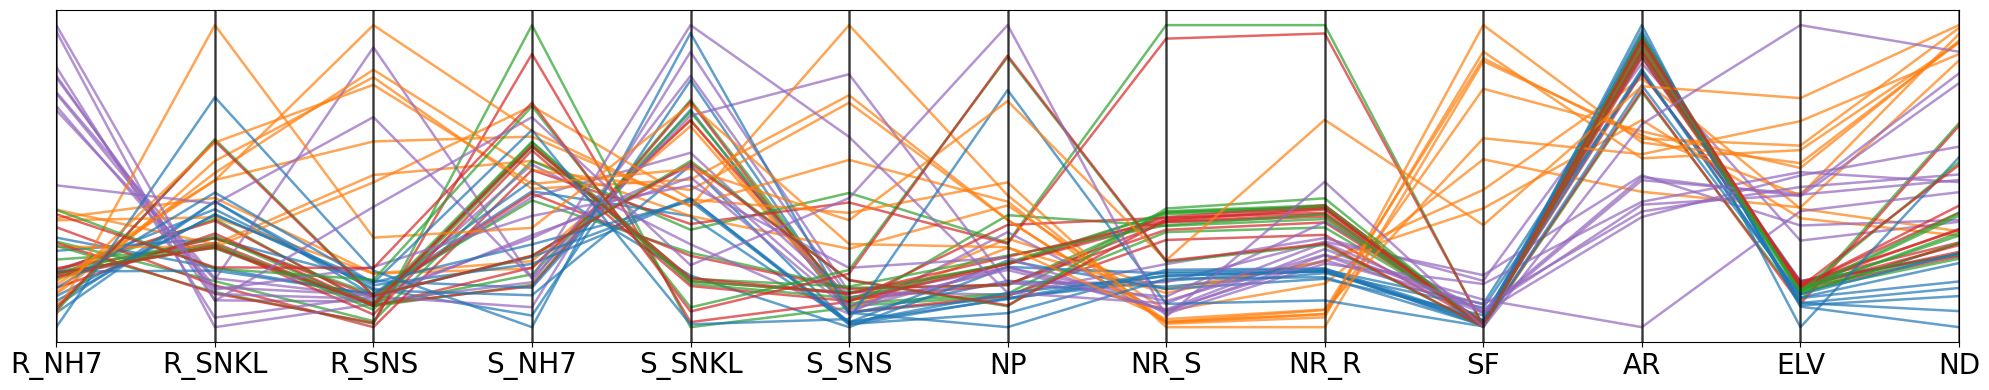

In [19]:
from pandas.plotting import parallel_coordinates

columns = [
    "R_NH7", 
    "R_SNKL",
    "R_SNS",
    "S_NH7", 
    "S_SNKL",
    "S_SNS",
    "NP",
    "NR_S",
    "NR_R",
    "SF",
    "AR",
    "ELV",
    "ND",
    "alg"
]

mapper = dict(zip(pivot_df.columns,columns))

pivot_df = pivot_df.rename(columns=mapper)

df_numeric = pivot_df.select_dtypes(include='number')
df_normalized = (df_numeric - df_numeric.min()) / (df_numeric.max() - df_numeric.min())

df_normalized['alg'] = pivot_df['alg']


fig,ax = plt.subplots()
parallel_coordinates(df_normalized,"alg",ax=ax,color=[cm.get_cmap("tab10")(i) for i in range(5)])

for i, line in enumerate(ax.get_lines()):
    line.set_alpha(0.7)
    line.set_linewidth(1.8)

ax.set_yticks([])
ax.legend_.remove()
ax.tick_params(axis='x', labelsize=20)
fig.set_size_inches(20,4)
fig.tight_layout()
fig.savefig("figures/pc.pdf",dpi=200)

/tmp/ipykernel_680257/3307755318.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  Line2D([0], [0], color=cm.get_cmap("tab10")(0), linestyle='-', linewidth=10, label='Union_FR'),
/tmp/ipykernel_680257/3307755318.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  Line2D([0], [0], color=cm.get_cmap("tab10")(1), linestyle='-', linewidth=10, label='Union_UMAP'),
/tmp/ipykernel_680257/3307755318.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  Line2D([0], [0], 

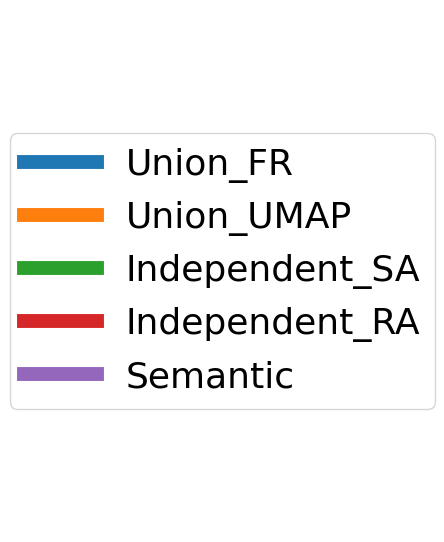

In [21]:
from matplotlib.lines import Line2D
plt.rcParams.update({'font.size': 26})


# Define your custom lines (styles and labels)
legend_elements = [
    Line2D([0], [0], color=cm.get_cmap("tab10")(0), linestyle='-', linewidth=10, label='Union_FR'),
    Line2D([0], [0], color=cm.get_cmap("tab10")(1), linestyle='-', linewidth=10, label='Union_UMAP'),
    Line2D([0], [0], color=cm.get_cmap("tab10")(2), linestyle='-', linewidth=10, label='Independent_SA'),
    Line2D([0], [0], color=cm.get_cmap("tab10")(3), linestyle='-', linewidth=10, label='Independent_RA'),
    Line2D([0], [0], color=cm.get_cmap("tab10")(4), linestyle='-', linewidth=10, label='Semantic'),            
]

# Create a new figure for the legend
fig, ax = plt.subplots()
ax.legend(handles=legend_elements, loc='center')
ax.axis('off')  # Hide axes

fig.set_size_inches(3,6)
fig.tight_layout()
plt.tight_layout()
plt.savefig("figures/PC_legend.pdf")